In this notebook, we aim to **replicate the results** obtained by *Walasek and Gajda* in the paper **"Fractional Differentiation and its Use in Machine Learning"**.


# Downloading data

In [ ]:
# ⚙️ Run this cell only once to download and save the data.
# After this, you can skip it and directly load the CSV files.

import yfinance as yf

start_date = "2010-06-01"
end_date = "2020-06-30"

# Download data (each index in its own DataFrame)
sp500_data  = yf.download('^GSPC',  start=start_date, end=end_date)
dax_data    = yf.download('^GDAXI', start=start_date, end=end_date)
nikkei_data = yf.download('^N225',  start=start_date, end=end_date)

# Save the data as CSV files
sp500_data.to_csv("sp500_data.csv")
dax_data.to_csv("dax_data.csv")
nikkei_data.to_csv("nikkei_data.csv")


# ▶️ Starting point

If you already have the historical data for the four indices saved as CSV files, you can **skip the previous cell** and start running from here.


In [1]:
# === Importing required libraries ===
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
import numpy as np
from fracdiff.sklearn import Fracdiff
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from tensorflow.keras.metrics import RootMeanSquaredError, MeanAbsoluteError
from tensorflow.keras import Sequential, Input
from sklearn.preprocessing import MinMaxScaler

In [2]:
# Function to read the CSV file and preprocess the data
def reading_file(file_name):
    """
    Read a CSV with a 2-row header (e.g., ('Price','Ticker')) and a date index,
    keep only the first header level ('Price'), and coerce all values to numeric.

    Parameters
    ----------
    file_name : str
        Path to the CSV.

    Returns
    -------
    pd.DataFrame
        DataFrame indexed by datetime, single-level columns, numeric dtype.
    """
    data = pd.read_csv(
        file_name,
        header=[0, 1],        # 2 header rows: ('Price', 'Ticker')
        index_col=0,          # first column is the date index
        parse_dates=True,
    )
    # Keep only the first level of the columns ('Price')
    data.columns = data.columns.get_level_values(0)
    # Ensure all entries are numeric
    data = data.apply(pd.to_numeric, errors="coerce")
    return data

# Function to add fractional differencing column to the dataframe
def add_frac_diff_column(series, order_diff, cols, mode):
    """
    Add differenced columns for each column in `cols` to `series`.
    ----------
    series : pd.DataFrame
        Input DataFrame (will be mutated and also returned).
    order_diff : float|int
        Fractional differencing order (if fractional) or integer lag (if not fractional).
    cols : list[str]
        Columns to transform.
    mode : str
        "fractional" or anything else (treated as integer differencing).

    Returns
    -------
    pd.DataFrame
        The same DataFrame with added columns.
    """

    if mode == "fractional":
        fracdiff = Fracdiff(order_diff, window=50) # the window size is now default=10
        for col in cols:		
            feature = series[[col]].astype(float).copy()
            new_column = f"{col}_fd"
            series[new_column] = fracdiff.fit_transform(feature).ravel() # No need to align since mode of FracDiff is not "valid"
    else:
        for col in cols:
            feature = series[col].copy()
            new_column = f"{col}_d"
            series[new_column] = feature.diff()
    return series

# Function to compute stationarity test statistics
def stationarity_values(series):
    """
    Compute ADF and KPSS test statistics .

    The series is cleaned with dropna() and cast to float before testing.

    Parameters
    ----------
    series : pd.Series or 1D array-like
        Input series.

    Returns
    -------
    tuple
        (adf_stat, adf_p, kpss_stat, kpss_p)
    """
    series = series.dropna().astype(float)
    a_stat, a_p, *_ = adfuller(series, autolag='AIC')
    k_stat, k_p, *_ = kpss(series)
    return a_stat, a_p, k_stat, k_p
    
# Function for training and evaluating models : it returns test metrics
def train_evaluate_model(train_data, test_data, target_train, target_test, n_features):
    """
    Build, train, and evaluate a shallow MLP:
    Input -> Dense(32, tanh) -> Dense(1, linear).
    Uses validation split, early stopping, and ReduceLROnPlateau.

    Parameters
    ----------
    train_data, test_data : array-like (n_samples, n_features)
        Feature matrices for train/test.
    target_train, target_test : array-like (n_samples,)
        Targets for train/test (scaled or original scale, as you prefer).
    n_features : int
        Number of input features.

    Returns
    -------
    list
        Keras evaluate() output on test set: [loss, rmse, mae].
    """
    model = Sequential([
        Input(shape=(n_features,)),
        Dense(32, activation='tanh'),
        Dense(1, activation='linear')
    ])
    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=[RootMeanSquaredError(name='rmse'), MeanAbsoluteError(name='mae')]
    )

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8, min_lr=1e-5)
    ]

    history = model.fit(
        train_data, target_train,
        validation_split=0.2,
        epochs=500,
        batch_size=32,
        shuffle=False,
        callbacks=callbacks,
        verbose=1
    )

    test_metrics = model.evaluate(test_data, target_test, verbose=0)
    return test_metrics

# Function to create the dataset

def prepare_data(series, cols, mode):
    """
    Prepare (fractional- or integer-differenced) OHLC features and next-day target.

    - Features: `cols` (must already exist in `series`)
    - Target: next-day Close_fd if mode == "fractional", else next-day Close_d
    - Drops rows with NaNs in features or target.
    - Splits into train/test by index. If `split_index` is None, uses 67%/33%.
    - Scales features and target with MinMaxScaler fit on TRAIN only.

    Parameters
    ----------
    series : pd.DataFrame
        Input DataFrame containing the required columns.
    cols : list[str]
        Feature columns to use (e.g., ['Close_fd','Open_fd','High_fd','Low_fd']).
    mode : str
        "fractional" or "integer" (chooses target column).
    split_index : int, optional
        Integer index at which to split train/test. If None, uses int(0.67 * n).

    Returns
    -------
    tuple
        (X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled)
    """
    dataset = series[cols].copy()
    if mode == "fractional":
        target = series['Close_fd'].shift(-1)
    else:
        target = series['Close_d'].shift(-1)

    # mask valid rows
    mask = dataset.notna().all(axis=1) & target.notna()
    X = dataset.loc[mask].astype(float).values
    y = target.loc[mask].astype(float).values.reshape(-1, 1)

    n = len(X)
    split_index = int(0.67 * n)

    X_train, X_test = X[:split_index], X[split_index:]
    y_train, y_test = y[:split_index], y[split_index:]

    # scale on TRAIN only
    x_scaler = MinMaxScaler().fit(X_train)
    y_scaler = MinMaxScaler().fit(y_train)

    X_train_s = x_scaler.transform(X_train)
    X_test_s  = x_scaler.transform(X_test)
    y_train_s = y_scaler.transform(y_train).ravel()
    y_test_s  = y_scaler.transform(y_test).ravel()

    return X_train_s, X_test_s, y_train_s, y_test_s


# Function to choose the right order of (fractional) differentiation for stationarity
def sweep_fractional_orders(series, d_list):
    """
    For a given univariate series (e.g., 'Close'), compute fractional differences
    for each d in d_list, align to the tail, and compute ADF stats.

    Parameters
    ----------
    series : pd.DataFrame
        DataFrame containing a 'Close' column.
    d_list : list[float]
        Fractional orders to evaluate.

    Returns
    -------
    list[dict]
        One dict per d: {
            'd': float,
            'series': pd.Series (fractionally differenced),
            'adf_stat': float,
            'adf_p': float,
        }
    """
    rows = []
    for d in d_list:
        frac = Fracdiff(d, window=50)
        X = series[['Close']]          
        X_fd = frac.fit_transform(X).ravel()
        s_fd = pd.Series(X_fd)        								
        a_stat, a_p, _ , _ = stationarity_values(s_fd)
        rows.append({
            "d": d, "series": s_fd,
            "adf_stat": a_stat, "adf_p": a_p,
        })
    return rows

def plot_close_diff_frac_one(title, df,
                             col_close="Close",
                             col_diff="Close_d",
                             col_frac="Close_fd",
                             use_quantiles=True):
    """
    Plot the original, integer-differenced, and fractionally differenced series
    on the same figure using twin y-axes.
    Left axis → original series.
    Right axis → differenced series (integer + fractional).
    """
    fig, ax1 = plt.subplots(figsize=(12, 5))

    # --- Left axis: original prices ---
    ax1.plot(df.index, df[col_close], lw=1.6, color="black", label="Original (Close)")
    ax1.set_ylabel("Closing Price (original series)")
    ax1.set_xlabel("Date")

    # --- Right axis: integer and fractional differences ---
    ax2 = ax1.twinx()
    ax2.plot(df.index, df[col_diff], lw=1.0, color="tab:blue", label="Diff (d=1)")
    ax2.plot(df.index, df[col_frac], lw=1.0, color="tab:orange", label="Frac diff (d*)")
    ax2.set_ylabel("Closing Price (differenced)")

    # --- Automatically adapt y-limits using quantiles (robust to outliers) ---
    if use_quantiles:
        def set_ylim_by_quantiles(ax, y, q=(0.01, 0.99), pad=0.08):
            y = np.asarray(y, float)
            y = y[~np.isnan(y)]
            if y.size == 0: 
                return
            lo, hi = np.quantile(y, q)
            span = hi - lo if hi > lo else abs(hi) + 1.0
            ax.set_ylim(lo - pad * span, hi + pad * span)

        set_ylim_by_quantiles(ax1, df[col_close])
        ys_right = []
        if col_diff in df:
            ys_right.append(df[col_diff].values)
        if col_frac in df:
            ys_right.append(df[col_frac].values)
        if ys_right:
            ycat = np.concatenate([y[~np.isnan(y)] for y in ys_right]) if len(ys_right) > 1 else ys_right[0]
            set_ylim_by_quantiles(ax2, ycat)

    # --- Legend and layout ---
    lines = ax1.get_lines() + ax2.get_lines()
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc="best")

    ax1.set_title(title)
    ax1.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    

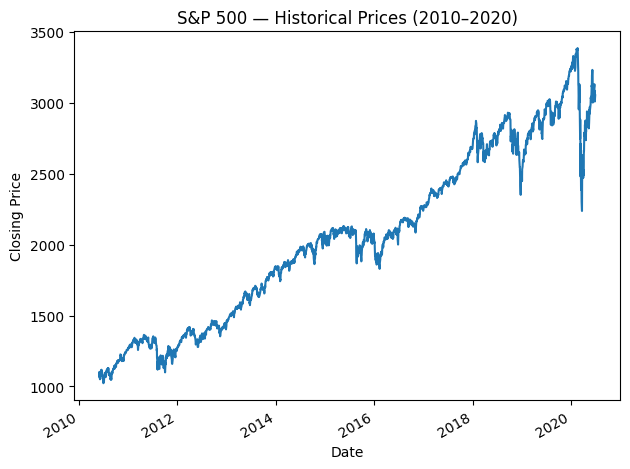

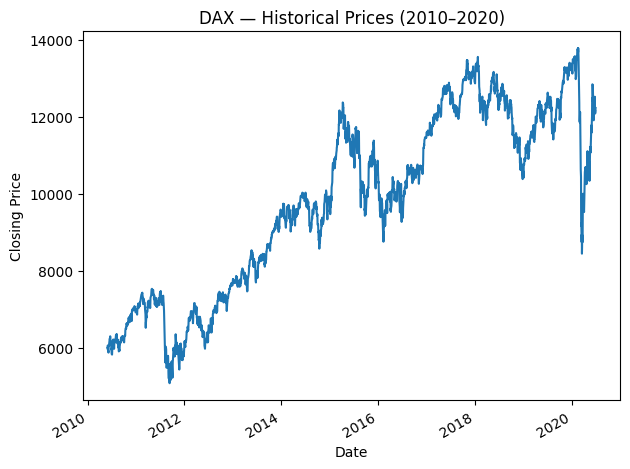

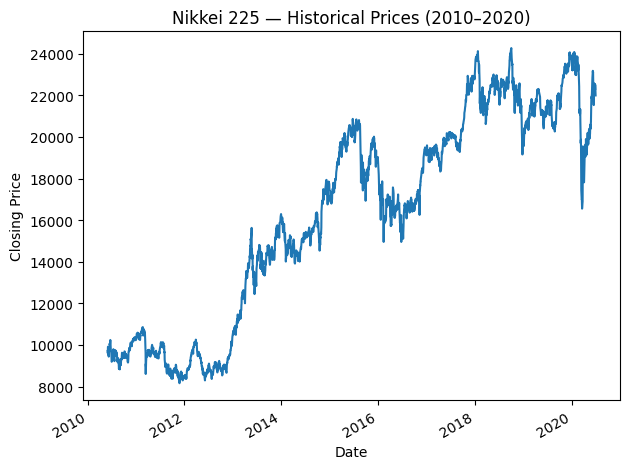

In [3]:
# WIG20 is excluded since its data start only from 2013-03-05 (without clear reason)
sp500 = reading_file("sp500_data.csv")
dax = reading_file("dax_data.csv")
nikkei = reading_file("nikkei_data.csv")

# Plot each index
for name, df in {
    "S&P 500": sp500,
    "DAX": dax,
    "Nikkei 225": nikkei,
}.items():
    df["Close"].plot(title=f"{name} — Historical Prices (2010–2020)")
    plt.xlabel("Date")
    plt.ylabel("Closing Price")
    plt.tight_layout()
    plt.show()


In the following, we analyze the **stationarity** of the time series by applying **unit root tests** such as *ADF* and *KPSS*.


In [4]:
results = []
for name, df in {
    "S&P 500": sp500,
    "DAX": dax,
    "Nikkei 225": nikkei,
}.items():
    a_stat, a_p, k_stat, k_p = stationarity_values(df["Close"])
    results.append((
        name,
        f"{a_stat:.2f}\n({a_p:.2f})",
        f"{k_stat:.2f}\n({k_p:.2f})"
    ))

table = pd.DataFrame(results, columns=["Stock index", "ADF", "KPSS"]).set_index("Stock index")
display(table.style.set_properties(**{'white-space': 'pre-wrap'}))

/Users/fp/venvs/finance39/lib/python3.9/site-packages/statsmodels/tsa/stattools.py:2018: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  warnings.warn(
/Users/fp/venvs/finance39/lib/python3.9/site-packages/statsmodels/tsa/stattools.py:2018: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  warnings.warn(
/Users/fp/venvs/finance39/lib/python3.9/site-packages/statsmodels/tsa/stattools.py:2018: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  warnings.warn(


,ADF,KPSS
Stock index,,
S&P 500,-0.76 (0.83),8.03 (0.01)
DAX,-1.67 (0.45),7.33 (0.01)
Nikkei 225,-1.20 (0.67),7.32 (0.01)


### 📊 Stationarity Tests: ADF vs KPSS

<div style="display: flex; justify-content: space-between; gap: 2rem;">

<div style="flex: 1;">

#### 🔹 Augmented Dickey–Fuller (ADF)
- **H₀:** the series has a *unit root* → **non-stationary**  
- **H₁:** the series is **stationary**

| Result | Interpretation |
|:--------|:----------------|
| ✅ Accept H₀ | → Series is **non-stationary** |
| ❌ Reject H₀ | → Series is **stationary** |

</div>

<div style="flex: 1;">

#### 🔹 Kwiatkowski–Phillips–Schmidt–Shin (KPSS)
- **H₀:** the series is *(trend-)stationary*  
- **H₁:** the series is **non-stationary**

| Result | Interpretation |
|:--------|:----------------|
| ✅ Accept H₀ | → Series is **stationary** |
| ❌ Reject H₀ | → Series is **non-stationary** |

</div>
</div>

#### 💡 About the *p-value*
- The **p-value** indicates the probability of observing the test statistic *under the null hypothesis*:
  - **p-value < 0.05** → **Reject H₀**
  - **p-value ≥ 0.05** → **Accept H₀**
- Hence:
  - For **ADF**, a small p-value (< 0.05) ⇒ reject H₀ ⇒ **stationary series**  
  - For **KPSS**, a small p-value (< 0.05) ⇒ reject H₀ ⇒ **non-stationary series**
- Extremely small p-values in KPSS (sometimes triggering warnings) mean the series is **strongly non-stationary** —  
  the test statistic lies beyond the available critical values.

---

- If both tests suggest non-stationarity → apply (fractional) **differencing**.


> **Remark.** The three indices don’t share exactly the same trading calendar — holidays/timezones lead to **different date lengths** and missing days per index. That’s normal for international markets.  


# Differentiating the time series

In what follows we apply **integer** and **fractional** differencing to obtain
(time-)**stationary** series better suited for forecasting.

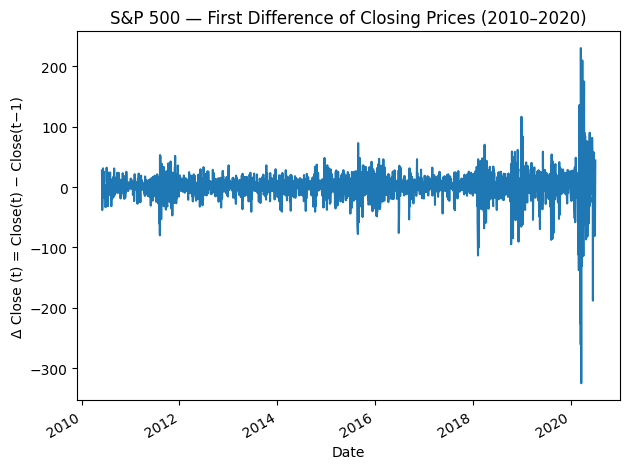

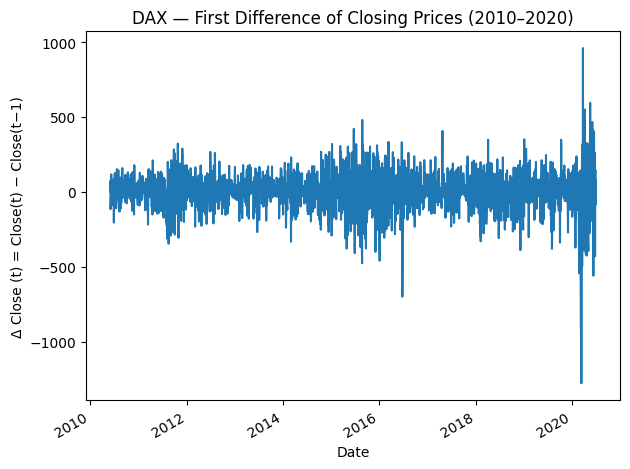

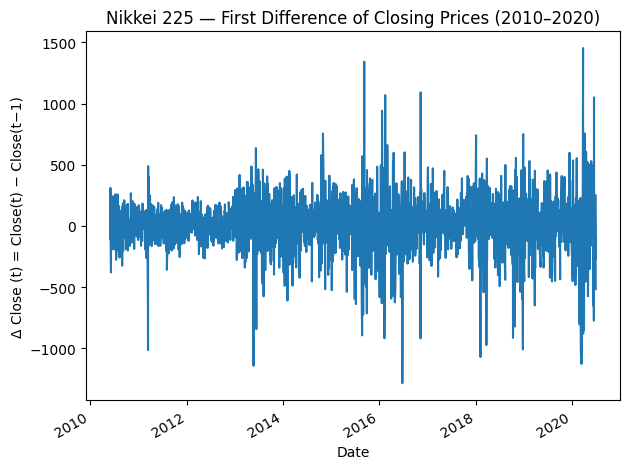

In [5]:
# === Integer differencing (d = 1) ===
base_cols = ['Open','High','Low','Close']
for name, df in {
    "S&P 500": sp500,
    "DAX": dax,
    "Nikkei 225": nikkei,
}.items():
    # Add first difference columns to the dataframe
    df = add_frac_diff_column(df, order_diff=1, cols=base_cols, mode="integer")
    df["Close_d"].plot(title=f"{name} — First Difference of Closing Prices (2010–2020)")
    plt.xlabel("Date")
    plt.ylabel("Δ Close (t) = Close(t) − Close(t−1)")
    plt.tight_layout()
    plt.show()

In [6]:
# === ADF & KPSS on the differenced series (quick check) ===
results_diff = []
for name, df in {
    "S&P 500": sp500,
    "DAX": dax,
    "Nikkei 225": nikkei,
}.items():
    a_stat, a_p, k_stat, k_p = stationarity_values(df["Close_d"])
    results_diff.append((
        name,
        f"{a_stat:.2f}\n({a_p:.2f})",
        f"{k_stat:.2f}\n({k_p:.2f})"
    ))

table_diff = pd.DataFrame(results_diff, columns=["Stock index", "ADF (Δ)", "KPSS (Δ)"]).set_index("Stock index")
display(table_diff.style.set_properties(**{'white-space': 'pre-wrap'}))

/Users/fp/venvs/finance39/lib/python3.9/site-packages/statsmodels/tsa/stattools.py:2022: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  warnings.warn(
/Users/fp/venvs/finance39/lib/python3.9/site-packages/statsmodels/tsa/stattools.py:2022: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  warnings.warn(
/Users/fp/venvs/finance39/lib/python3.9/site-packages/statsmodels/tsa/stattools.py:2022: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  warnings.warn(


,ADF (Δ),KPSS (Δ)
Stock index,,
S&P 500,-11.13 (0.00),0.01 (0.10)
DAX,-17.56 (0.00),0.04 (0.10)
Nikkei 225,-33.71 (0.00),0.04 (0.10)


As expected, the **first difference** (d = 1) yields (near-)stationary series. The ADF statistic typically moves from around **−1/−2** to **−20/−30**, indicating strong evidence against a unit root. This suggests that a **fractional** order might suffice to reach stationarity while **preserving more memory** than d = 1.


# Fractional Differentiation

We now apply **fractional differencing** to the closing prices.  
Our goal is to obtain (near-)stationarity while retaining as much memory of the original series as possible.  


## Finding the best order of differentiation

We now test a range of fractional orders $ d \in \{0.1, 0.2, \ldots, 0.9\} $ to identify the smallest value that yields (near-)stationarity for each index.

In [7]:
# === Sweep d for each index and summarize ===
d_grid = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

summary_tables = {}

for name, df in {
    "S&P 500": sp500,
    "DAX": dax,
    "Nikkei 225": nikkei,
}.items():
    rows = sweep_fractional_orders(df, d_grid)  # expects a Series
    table_rows = []
    for r in rows:
        table_rows.append((
            f"d = {r['d']:.1f}",
            f"{r['adf_stat']:.2f}\n({r['adf_p']:.3f})",
        ))
    tbl = pd.DataFrame(table_rows, columns=["Order d", "ADF"]).set_index("Order d")
    summary_tables[name] = tbl

# Display tables
for name, tbl in summary_tables.items():
    print(f"=== {name} — fractional differencing sweep ===")
    display(tbl.style.set_properties(**{'white-space': 'pre-wrap'}))

/Users/fp/venvs/finance39/lib/python3.9/site-packages/statsmodels/tsa/stattools.py:2018: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  warnings.warn(
/Users/fp/venvs/finance39/lib/python3.9/site-packages/statsmodels/tsa/stattools.py:2018: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  warnings.warn(
/Users/fp/venvs/finance39/lib/python3.9/site-packages/statsmodels/tsa/stattools.py:2018: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  warnings.warn(
/Users/fp/venvs/finance39/lib/python3.9/site-packages/statsmodels/tsa/stattools.py:2018: InterpolationWarning: The test statistic is outside of the range of p-values available in th

=== S&P 500 — fractional differencing sweep ===


/Users/fp/venvs/finance39/lib/python3.9/site-packages/statsmodels/tsa/stattools.py:2022: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  warnings.warn(


,ADF
Order d,
d = 0.1,-0.74 (0.836)
d = 0.2,-0.81 (0.816)
d = 0.3,-1.15 (0.694)
d = 0.4,-1.72 (0.419)
d = 0.5,-2.59 (0.096)
d = 0.6,-3.86 (0.002)
d = 0.7,-5.70 (0.000)
d = 0.8,-8.10 (0.000)
d = 0.9,-10.34 (0.000)


=== DAX — fractional differencing sweep ===


,ADF
Order d,
d = 0.1,-1.74 (0.413)
d = 0.2,-1.91 (0.325)
d = 0.3,-2.35 (0.156)
d = 0.4,-3.25 (0.017)
d = 0.5,-4.34 (0.000)
d = 0.6,-5.78 (0.000)
d = 0.7,-7.35 (0.000)
d = 0.8,-8.91 (0.000)
d = 0.9,-10.04 (0.000)


=== Nikkei 225 — fractional differencing sweep ===


,ADF
Order d,
d = 0.1,-1.16 (0.690)
d = 0.2,-1.44 (0.561)
d = 0.3,-2.02 (0.278)
d = 0.4,-2.95 (0.039)
d = 0.5,-4.34 (0.000)
d = 0.6,-5.87 (0.000)
d = 0.7,-8.11 (0.000)
d = 0.8,-10.41 (0.000)
d = 0.9,-35.07 (0.000)


The goal is to analyze how the ADF statistic varies with the order of fractional differencing, in order to identify the optimal degree ( $ d^* $ ) that achieves stationarity.
The ADF test is computed only on the **closing price** series, which serves as a representative indicator of stationarity.
Once the optimal order ( $ d^* $ ) is determined, the same value is then applied to **all features** (Open, High, Low, Close) that will be used as inputs to the neural network.


/Users/fp/venvs/finance39/lib/python3.9/site-packages/statsmodels/tsa/stattools.py:2018: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  warnings.warn(
/Users/fp/venvs/finance39/lib/python3.9/site-packages/statsmodels/tsa/stattools.py:2018: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  warnings.warn(
/Users/fp/venvs/finance39/lib/python3.9/site-packages/statsmodels/tsa/stattools.py:2018: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  warnings.warn(
/Users/fp/venvs/finance39/lib/python3.9/site-packages/statsmodels/tsa/stattools.py:2018: InterpolationWarning: The test statistic is outside of the range of p-values available in th

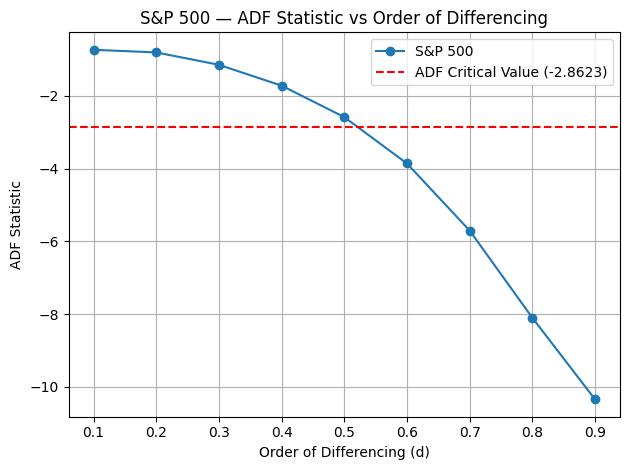

Estimated order of stationarity for S&P 500: d* ≈ 0.522
For S&P 500, the minimum d for stationarity is approximately: 0.6


/Users/fp/venvs/finance39/lib/python3.9/site-packages/statsmodels/tsa/stattools.py:2018: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  warnings.warn(
/Users/fp/venvs/finance39/lib/python3.9/site-packages/statsmodels/tsa/stattools.py:2018: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  warnings.warn(
/Users/fp/venvs/finance39/lib/python3.9/site-packages/statsmodels/tsa/stattools.py:2018: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  warnings.warn(
/Users/fp/venvs/finance39/lib/python3.9/site-packages/statsmodels/tsa/stattools.py:2018: InterpolationWarning: The test statistic is outside of the range of p-values available in th

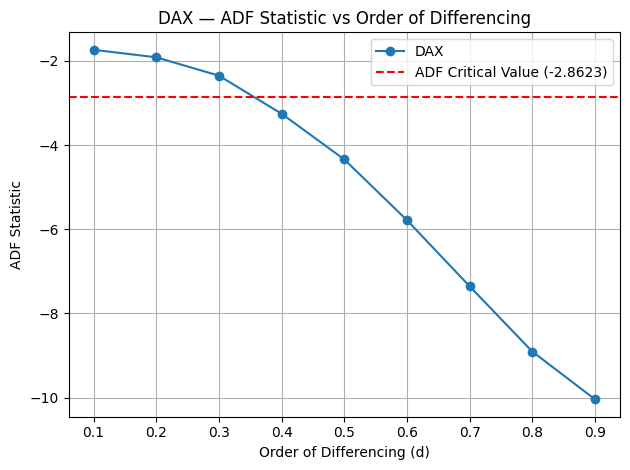

Estimated order of stationarity for DAX: d* ≈ 0.357
For DAX, the minimum d for stationarity is approximately: 0.4


/Users/fp/venvs/finance39/lib/python3.9/site-packages/statsmodels/tsa/stattools.py:2018: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  warnings.warn(
/Users/fp/venvs/finance39/lib/python3.9/site-packages/statsmodels/tsa/stattools.py:2018: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  warnings.warn(
/Users/fp/venvs/finance39/lib/python3.9/site-packages/statsmodels/tsa/stattools.py:2018: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  warnings.warn(
/Users/fp/venvs/finance39/lib/python3.9/site-packages/statsmodels/tsa/stattools.py:2018: InterpolationWarning: The test statistic is outside of the range of p-values available in th

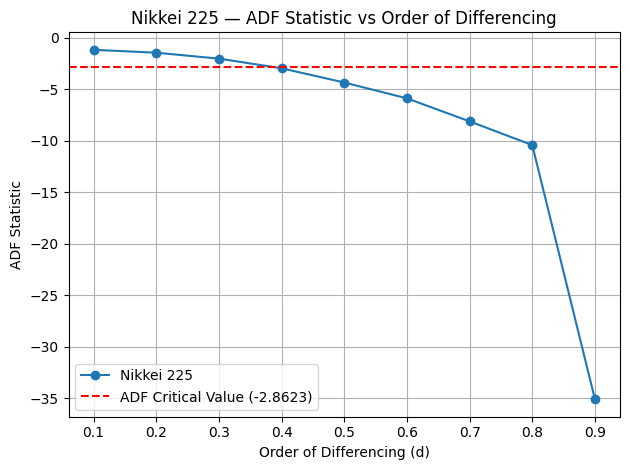

Estimated order of stationarity for Nikkei 225: d* ≈ 0.390
For Nikkei 225, the minimum d for stationarity is approximately: 0.4


In [20]:
# Plot the ADF results vs order of differentiation
frac_orders = []
for name, df in {
	"S&P 500": sp500,
	"DAX": dax,
	"Nikkei 225": nikkei,
}.items():
	cval = -2.8623  # ADF critical value at 5% for n > 1000
	rows = sweep_fractional_orders(df, d_grid)
	d_values = [r['d'] for r in rows]
	adf_stats = [r['adf_stat'] for r in rows]
	plt.title(f"{name} — ADF Statistic vs Order of Differencing")
	plt.plot(d_values, adf_stats, marker='o', label=name)
	plt.axhline(y=cval, color='r', linestyle='--', label='ADF Critical Value (-2.8623)')
	plt.xlabel("Order of Differencing (d)")
	plt.ylabel("ADF Statistic")
	plt.legend()
	plt.grid()
	plt.tight_layout()
	plt.show()
	# Intersection between ADF stats and critical value
	# find first crossing where ADF goes from > cval to <= cval
	d_values  = np.asarray(d_values, dtype=float)
	adf_stats = np.asarray(adf_stats, dtype=float)
	mask = (adf_stats[:-1] > cval) & (adf_stats[1:] <= cval)
	idx = np.where(mask)[0]
	i = idx[0]
	# linear interpolation
	d1, d2 = d_values[i], d_values[i+1]
	a1, a2 = adf_stats[i], adf_stats[i+1]
	d_star = d1 + (cval - a1) * (d2 - d1) / (a2 - a1)
	print(f"Estimated order of stationarity for {name}: d* ≈ {d_star:.3f}")
	frac_orders.append((name, d_star))
	for r in rows:
		if r['adf_stat'] < -2.8623:
			print(f"For {name}, the minimum d for stationarity is approximately: {r['d']:.1f}")
			break
		

After you pick the "best" order of differentiation you can add the fractional differentiation column and prepare the dataset for the neural network the see the performance of integer differentiation ( d = 1) vs fractional differentiation.

In [23]:
# ---- Given fractional orders --------------------------------------------------
frac_orders = dict(frac_orders)


sp500 = add_frac_diff_column(sp500, order_diff=frac_orders["S&P 500"],  cols=base_cols, mode="fractional")


dax   = add_frac_diff_column(dax,   order_diff=frac_orders["DAX"],    cols=base_cols, mode="fractional")


nikkei = add_frac_diff_column(nikkei, order_diff=frac_orders["Nikkei 225"], cols=base_cols, mode="fractional")


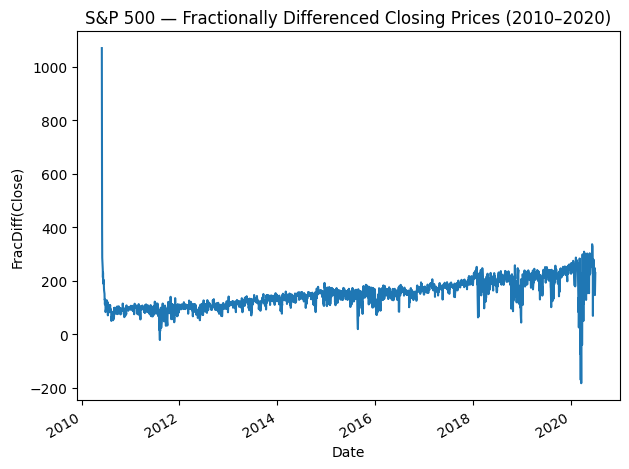

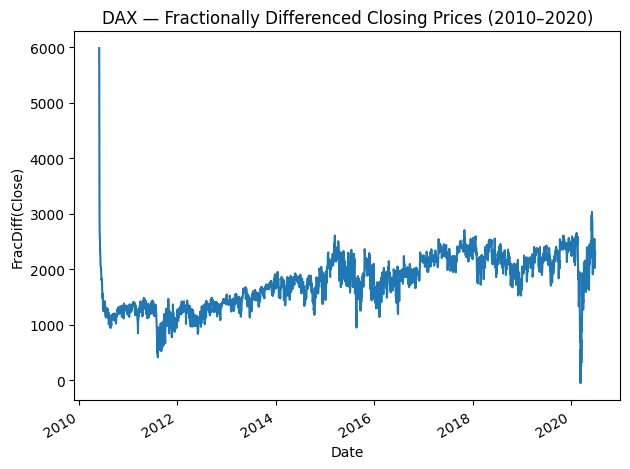

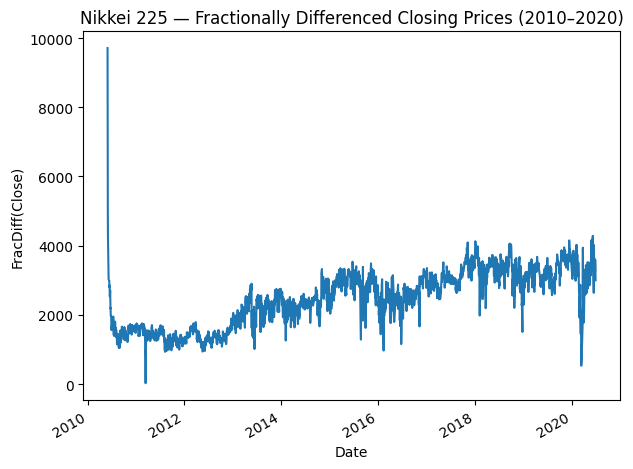

In [24]:
# === Plot fractionally differenced series ===
for name, df in {
    "S&P 500": sp500,
    "DAX": dax,
    "Nikkei 225": nikkei,
}.items():
    # Skip first few NaNs due to differencing
    df["Close_fd"].plot(title=f"{name} — Fractionally Differenced Closing Prices (2010–2020)")
    plt.xlabel("Date")
    plt.ylabel("FracDiff(Close)")
    plt.tight_layout()
    plt.show()

In [25]:
# === Stationarity tests on fractionally differenced series ===
results_fd = []
for name, df in {
    "S&P 500": sp500,
    "DAX": dax,
    "Nikkei 225": nikkei,
}.items():
    a_stat, a_p, k_stat, k_p = stationarity_values(df["Close_fd"])  
    results_fd.append((
        name,
        f"{a_stat:.2f}\n({a_p:.2f})",
        f"{k_stat:.2f}\n({k_p:.2f})"
    ))

table_fd = pd.DataFrame(results_fd, columns=["Stock index", "ADF", "KPSS"]).set_index("Stock index")
display(table_fd.style.set_properties(**{'white-space': 'pre-wrap'}))

/Users/fp/venvs/finance39/lib/python3.9/site-packages/statsmodels/tsa/stattools.py:2018: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  warnings.warn(
/Users/fp/venvs/finance39/lib/python3.9/site-packages/statsmodels/tsa/stattools.py:2018: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  warnings.warn(
/Users/fp/venvs/finance39/lib/python3.9/site-packages/statsmodels/tsa/stattools.py:2018: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  warnings.warn(


,ADF,KPSS
Stock index,,
S&P 500,-2.82 (0.06),6.81 (0.01)
DAX,-2.59 (0.10),6.30 (0.01)
Nikkei 225,-2.84 (0.05),6.67 (0.01)


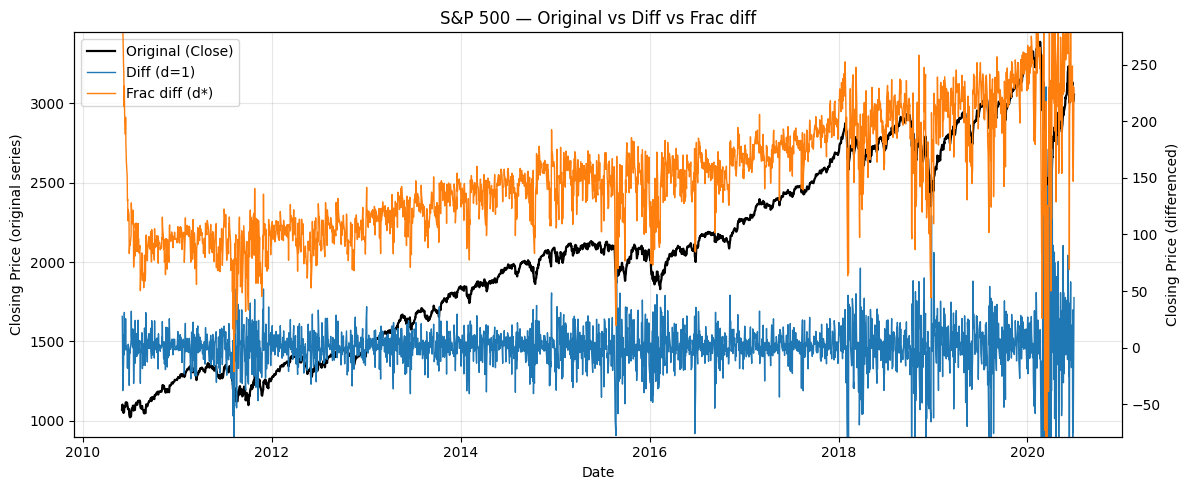

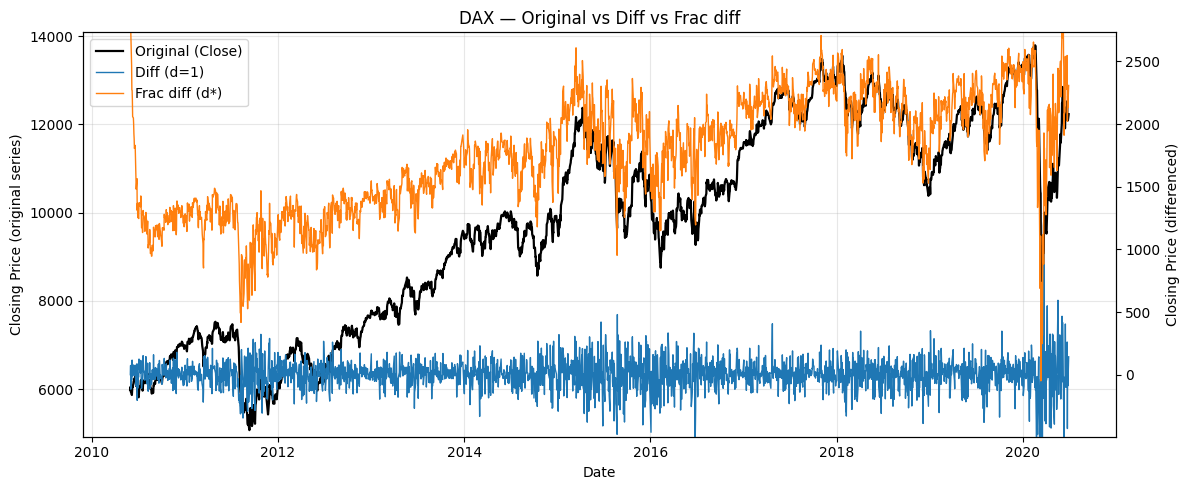

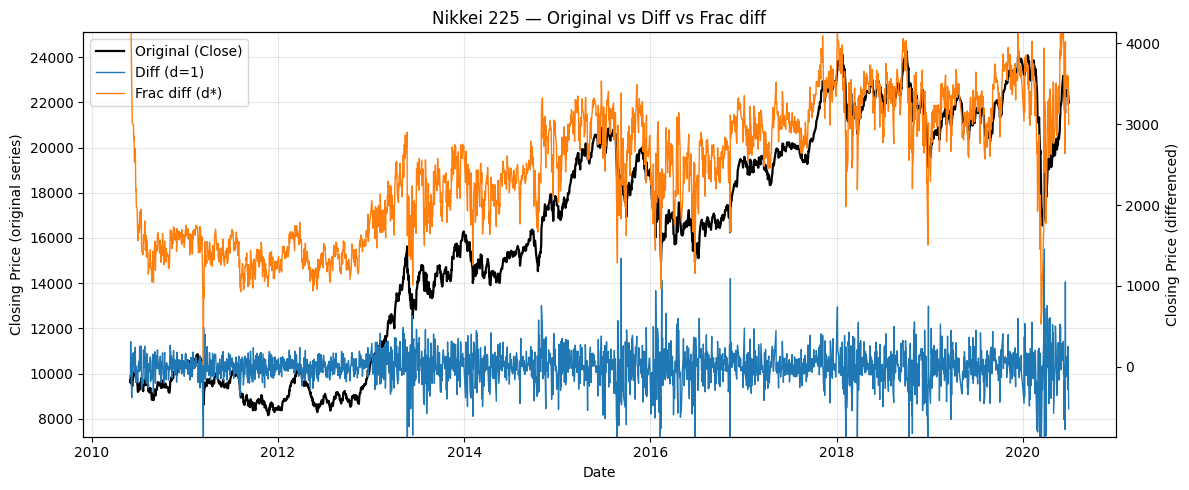

In [26]:
# === Combined visualization: original vs diff vs frac diff ===
plot_close_diff_frac_one("S&P 500 — Original vs Diff vs Frac diff", sp500)
plot_close_diff_frac_one("DAX — Original vs Diff vs Frac diff", dax)
plot_close_diff_frac_one("Nikkei 225 — Original vs Diff vs Frac diff", nikkei)


> **Personal observation:**
> From the combined evidence of the ADF and KPSS tests, we can infer that the optimal degree of fractional differencing is roughly **0.6–0.7** for the S&P 500, **0.0–0.1** for the DAX, and **0.4–0.5** for the Nikkei 225.
> These ranges indicate that each index requires a different level of memory adjustment to achieve (near-)stationarity.

# ANN 

In what follows, we specify a shallow feed-forward neural network (one hidden layer) that takes the daily OHLC (Open, High, Low, Close) values of each index (already differentiaed and therefore stationary) as inputs and predicts the next-day closing price. This is a one-step-ahead forecasting setup. The rationale is that fractional differencing preserves long-memory features while improving stationarity, so past information is effectively embedded in the current inputs, making a one-step model appropriate.

In [14]:
# ---- Feature sets -------------------------------------------------------------
fd_cols   = ['Close_fd','Open_fd','High_fd','Low_fd']
diff_cols = ['Close_d','Open_d','High_d','Low_d']

# ---- Prepare scaled splits  using the NEW prepare_data ---------------
# S&P 500 — fractional
X_sp500_fd_tr, X_sp500_fd_te, y_sp500_fd_tr, y_sp500_fd_te = prepare_data(sp500, fd_cols, "fractional")

# S&P 500 — integer
X_sp500_d_tr,  X_sp500_d_te,  y_sp500_d_tr,  y_sp500_d_te  = prepare_data(sp500, diff_cols, "integer")

# DAX — fractional
X_dax_fd_tr, X_dax_fd_te, y_dax_fd_tr, y_dax_fd_te = prepare_data(dax, fd_cols, "fractional")

# DAX — integer
X_dax_d_tr,  X_dax_d_te,  y_dax_d_tr,  y_dax_d_te  = prepare_data(dax, diff_cols, "integer")

# Nikkei — fractional
X_nikkei_fd_tr, X_nikkei_fd_te, y_nikkei_fd_tr, y_nikkei_fd_te = prepare_data(nikkei, fd_cols, "fractional")

# Nikkei — integer
X_nikkei_d_tr,  X_nikkei_d_te,  y_nikkei_d_tr,  y_nikkei_d_te  = prepare_data(nikkei, diff_cols, "integer")


In [15]:
# ---- Train & evaluate (your shallow MLP) -------------------------------------
results = {}
results["sp500_fd"]  = train_evaluate_model(X_sp500_fd_tr,  X_sp500_fd_te,  y_sp500_fd_tr,  y_sp500_fd_te,  n_features=4)
results["sp500_d"]   = train_evaluate_model(X_sp500_d_tr,   X_sp500_d_te,   y_sp500_d_tr,   y_sp500_d_te,   n_features=4)

results["dax_fd"]    = train_evaluate_model(X_dax_fd_tr,    X_dax_fd_te,    y_dax_fd_tr,    y_dax_fd_te,    n_features=4)
results["dax_d"]     = train_evaluate_model(X_dax_d_tr,     X_dax_d_te,     y_dax_d_tr,     y_dax_d_te,     n_features=4)

results["nikkei_fd"] = train_evaluate_model(X_nikkei_fd_tr, X_nikkei_fd_te, y_nikkei_fd_tr, y_nikkei_fd_te, n_features=4)
results["nikkei_d"]  = train_evaluate_model(X_nikkei_d_tr,  X_nikkei_d_te,  y_nikkei_d_tr,  y_nikkei_d_te,  n_features=4)

# ---- Pretty print -------------------------------------------------------------
for k, v in results.items():
    loss, rmse, mae = v
    print(f"{k:10s} -> Loss={loss:.6f} | RMSE={rmse:.6f} | MAE={mae:.6f}")

Epoch 1/500
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0413 - mae: 0.1651 - rmse: 0.1926 - val_loss: 0.0012 - val_mae: 0.0269 - val_rmse: 0.0351 - learning_rate: 0.0010
Epoch 2/500
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 891us/step - loss: 0.0065 - mae: 0.0679 - rmse: 0.0791 - val_loss: 0.0020 - val_mae: 0.0380 - val_rmse: 0.0442 - learning_rate: 0.0010
Epoch 3/500
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 871us/step - loss: 0.0043 - mae: 0.0522 - rmse: 0.0643 - val_loss: 0.0014 - val_mae: 0.0301 - val_rmse: 0.0368 - learning_rate: 0.0010
Epoch 4/500
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 895us/step - loss: 0.0038 - mae: 0.0511 - rmse: 0.0609 - val_loss: 0.0011 - val_mae: 0.0264 - val_rmse: 0.0338 - learning_rate: 0.0010
Epoch 5/500
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 929us/step - loss: 0.0033 - mae: 0.0481 - rmse: 0.0565 - val_loss: 0.0010 - val_mae: 0.0243 - val_rmse: 0.0322 - learning_rate: 0.0010
Epoch 6/500
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 908us/step - loss: 0.0028 - mae: 0.0446 - rmse: 0.0522 - val_loss: 9.9078e-

In [16]:
def compare_models(results, metric="rmse"):
    idx = {"loss":0, "rmse":1, "mae":2}[metric]
    rows = []
    for name in ["sp500", "dax", "nikkei"]:
        base = results[f"{name}_d"][idx]     # integer-diff (baseline)
        cand = results[f"{name}_fd"][idx]    # fractional-diff (candidate)
        rows.append({
            "index": name.upper(),
            f"{metric}_integer": base,
            f"{metric}_fractional": cand,
            "abs_improvement": base - cand,                 # + => fractional better
            "pct_improvement": 100.0 * (base - cand) / base,
        })
    df = pd.DataFrame(rows)
    # Optional: add an average row for improvements
    avg = {
        "index": "AVERAGE",
        "abs_improvement": df["abs_improvement"].mean(),
        "pct_improvement": df["pct_improvement"].mean(),
    }
    return df, avg

for m in ["loss","rmse","mae"]:
    df, avg = compare_models(results, metric=m)
    print("\n" + m.upper())
    print(df.to_string(index=False, float_format=lambda x: f"{x:.6f}"))
    print(f"AVERAGE  Δ={avg['abs_improvement']:.6f}   Δ%={avg['pct_improvement']:.2f}% ")



LOSS
 index  loss_integer  loss_fractional  abs_improvement  pct_improvement
 SP500      0.059740         0.004926         0.054814        91.753844
   DAX      0.015175         0.002220         0.012956        85.373523
NIKKEI      0.008997         0.002412         0.006586        73.193774
AVERAGE  Δ=0.024785   Δ%=83.44% 

RMSE
 index  rmse_integer  rmse_fractional  abs_improvement  pct_improvement
 SP500      0.244418         0.070187         0.174230        71.283878
   DAX      0.123188         0.047113         0.076075        61.755424
NIKKEI      0.094855         0.049111         0.045744        48.225273
AVERAGE  Δ=0.098683   Δ%=60.42% 

MAE
 index  mae_integer  mae_fractional  abs_improvement  pct_improvement
 SP500     0.136561        0.046014         0.090546        66.304848
   DAX     0.081413        0.033266         0.048147        59.139161
NIKKEI     0.065118        0.037553         0.027565        42.330491
AVERAGE  Δ=0.055419   Δ%=55.92% 
